In [ ]:
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import datetime

In [ ]:
def cpi_convert():
    df = pd.read_excel('historical-cpi-u-202602.xlsx', header=None)
    data = df.iloc[5:119].copy()
    data.columns = ['indent', 'Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    data = data[['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']].copy()
    data['Year'] = data['Year'].astype(int)

    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    melted = data.melt(id_vars='Year', value_vars=months, var_name='Month', value_name='CPI')
    melted = melted.sort_values(['Year']).reset_index(drop=True)
    melted['CPI'] = pd.to_numeric(melted['CPI'].replace({'–': None, '-': None}), errors='coerce')
    melted = melted.dropna(subset=['CPI'])
    melted['Date'] = melted['Month'] + '-' + melted['Year'].astype(str)
    melted = melted[['Date', 'CPI']].reset_index(drop=True)
    # melted.columns = ['Date', 'CPI']

    melted.to_excel('trial.xlsx', index=False)
cpi_convert()


In [31]:
[i for i in range(1, 13)]

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

In [ ]:
def cpi_convert():
    df = pd.read_excel('historical-cpi-u-202602.xlsx', header=None)
    data = df.iloc[5:119].copy()
    num_months = [str(i) for i in range(1, 13)]
    data.columns = ['indent', 'Year'] + num_months
    data = data.drop(columns= ['indent'])
    
    # Combining the dataframe into a single column
    data = data.melt(id_vars='Year', value_vars=num_months, var_name='Month', value_name='CPI')
    data['Date'] = pd.to_datetime(data['Year'].astype(str) + data['Month'], format='%Y%m').dt.strftime('%Y-%m')

    data = data.sort_values(['Date']).reset_index(drop=True)
    data = data[['Date', 'CPI']]
    data = data[data['CPI'] != '–']

    data.to_excel('historical-cpi-u-reorganized.xlsx', index=False)

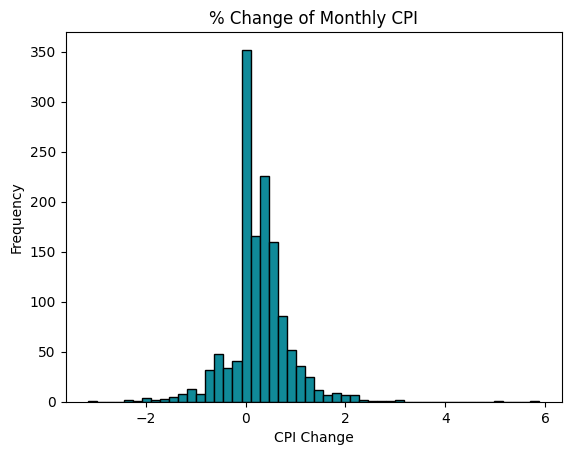

In [45]:
df = pd.read_excel('historical-cpi-u-reorganized.xlsx')
df['Change%'] = df['CPI'].pct_change()*100
df = df.dropna()

plt.hist(df['Change%'], bins=50, color='#108A99', edgecolor='black')
plt.title("% Change of Monthly CPI")
plt.xlabel("CPI Change")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df.nlargest(n=20, columns=['Change%'])
df.nsmallest(n=20, columns=['Change%'])

,Month-Year,CPI,Change%
48,Oct-1917,13.500,26.168224
84,Apr-1920,20.300,25.308642
408,Aug-1947,22.500,24.309392
72,Jul-1919,17.400,22.535211
60,May-1918,14.500,20.833333
396,Nov-1946,21.300,19.662921
405,Dec-1946,21.500,17.486339
804,Apr-1980,81.000,17.221418
348,Sep-1942,16.500,15.384615
80,Dec-1919,18.900,15.243902


In [ ]:
# python anywhere or streamlit
# investing.com for histroical data, udpate with yahoo

data = [1,2,3,4,5]
num_simulations = 10000
mean = np.mean(data)
std_dev = np.std(data)
pct_to_target = np.random.normal(mean, std_dev, num_simulations).round(2)
print(f"Mean Predicted Cost: {pct_to_target.mean():.2f}")
print(f"95th Percentile (Worst Case): {np.percentile(pct_to_target, 95):.2f}")
plt.hist(pct_to_target, bins=50, edgecolor='white')
plt.ylabel('frequency')
plt.show()


# display S&P returns
# Simulate MC simulation based on historical data
# display distributions of returns after 1 year with VaR and ES
# Compare to the CPI 

# hmmlearn for HMM